# Preprocessing

Cleaning the raw data and preparing the interim tables for feature engineering.

- type conversion (`price`, `bathrooms_text`, dates, identifiers),
- column selection and grouping of rare `property_type` categories,
- dropping missing values that cannot sensibly be imputed,
- VADER sentiment analysis of review text,
- writing to `data/interim/`.

Exploration (distributions, table coverage, conclusions) lives in `00-eda.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## Loading the raw data

In [2]:
reviews_df = pd.read_csv("../data/raw/reviews.csv")
sessions_df = pd.read_csv("../data/raw/sessions.csv")
listings_df = pd.read_csv("../data/raw/listings.csv")

## Column selection and type conversion

Columns are selected from the empirical analysis of their effect on `Y` carried out in `00-eda.ipynb` (ROC-AUC per `Listings` column, plus a leakage flag). It shows that:

- we take the **basic listing attributes**: `property_type`, `room_type`, `accommodates`, `bathrooms`, `bedrooms`, `price`, `neighbourhood_cleansed`,
- we add the two **strongest non-leaky host features**: `host_is_superhost` and `host_acceptance_rate` (AUC ~0.61, higher than most listing attributes), plus two booking-policy features, `minimum_nights` and `minimum_maximum_nights` (AUC ~0.57-0.59); the eight `*_nights` columns form two **independent** families (MIN-stay and MAX-stay), so we keep one representative from each and drop the rest as redundant within its family (verified in `00-eda`),
- we **drop the leaking columns** (a snapshot from the future: `review_scores_*`, `number_of_reviews*`, `availability_*`, `estimated_*`) - which is exactly why the review signal is computed with our own [VADER](https://github.com/cjhutto/vaderSentiment) sentiment *point-in-time*, rather than taken from the ready-made listing columns.

Rare `property_type` values are grouped into `"Other"` so that very sparse categories are not created.


In [3]:
listings_df['id'] = listings_df['id'].astype('Int64')
listings_df["accommodates"] = listings_df["accommodates"].astype("Int64")
listings_df["bedrooms"] = listings_df["bedrooms"].astype("Int64")

reviews_df["listing_id"] = reviews_df["listing_id"].astype("Int64")
reviews_df['date'] = pd.to_datetime(reviews_df['date'])

sessions_df["user_id"] = sessions_df["user_id"].astype("Int64")
sessions_df["listing_id"] = sessions_df["listing_id"].astype("Int64")
sessions_df['timestamp'] = pd.to_datetime(sessions_df['timestamp'])

In [4]:
sessions_df = sessions_df[["action", "user_id", "timestamp", "listing_id"]]
reviews_df = reviews_df[["listing_id", "date", "comments"]]
listing_df = listings_df[['id', 'property_type', 'room_type', 'accommodates',
                          'bathrooms_text', 'bedrooms', 'price', 'neighbourhood_cleansed',
                          'host_is_superhost', 'host_acceptance_rate',
                          'minimum_nights', 'minimum_maximum_nights']].copy()
listing_df = listing_df.rename(columns={'id': 'listing_id'})


In [5]:
# Parse price: "$1,098.00" -> 1098.0
listing_df['price'] = (
    listing_df['price']
    .str.replace(r'[$,]', '', regex=True)
    .astype(float)
)

# Parse bathrooms_text: "1 bath" -> 1.0, named 'bathrooms'
listing_df['bathrooms'] = (
    listing_df['bathrooms_text']
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)
listing_df = listing_df.drop(columns=['bathrooms_text'])

# host_is_superhost: 't'/'f' -> readable 'Yes'/'No' (categorical); missing stay NaN (-> 'Unknown' in 02 + one-hot encoding)
listing_df['host_is_superhost'] = listing_df['host_is_superhost'].map({'t': 'Yes', 'f': 'No'})
# host_acceptance_rate: '95%' -> 95.0 (numeric); missing stay NaN (-> imputed in 02)
listing_df['host_acceptance_rate'] = pd.to_numeric(
    listing_df['host_acceptance_rate'].astype(str).str.replace('%', '', regex=False),
    errors='coerce',
)

# Group rare property types into "Other" (keep types with >= 30 listings)
freq = listing_df['property_type'].value_counts()
rare_types = freq[freq < 30].index
listing_df['property_type'] = listing_df['property_type'].where(
    ~listing_df['property_type'].isin(rare_types), other='Other'
)

print(f"Listings po transformacji: {len(listing_df)}")
print(f"Kategorie w property_type: {listing_df['property_type'].nunique()}")
print(listing_df['property_type'].value_counts())


Listings po transformacji: 4598
Kategorie w property_type: 8
property_type
Entire rental unit             2145
Entire condo                    958
Private room in rental unit     170
Entire home                     167
Other                           116
Entire townhouse                 65
Private room in condo            60
Entire villa                     33
Name: count, dtype: int64


## Missing values

If a missing value cannot be sensibly imputed, the row is dropped.

### Sessions (`sessions.csv`)

From `sessions` we use `action`, `user_id`, `timestamp`, `listing_id`. The remaining columns (`booking_date`, `booking_duration`, `booking_id`) describe booked stays and do not enter the conversion model.

In [6]:
print(f"Null action: {sessions_df['action'].isnull().sum()}")
print(f"Null timestamp: {sessions_df['timestamp'].isnull().sum()}")
print(f'Null user_id: {sessions_df["user_id"].isnull().sum()}')

print()

print(
    f'Null listing in view listing: {((sessions_df["listing_id"].isnull()) & (sessions_df["action"] == "view_listing")).sum()}')
print(
    f'Null listing in book listing: {((sessions_df["listing_id"].isnull()) & (sessions_df["action"] == "book_listing")).sum()}')
print(
    f"Valid listing in book listing: {((sessions_df['action'] == 'book_listing') & (~sessions_df['listing_id'].isnull())).sum()}")

print()

print(f'Null user_id and timestamp: {(sessions_df["timestamp"].isnull() & sessions_df["user_id"].isnull()).sum()}')
print(
    f'Null timestamp and listing id: {(sessions_df["timestamp"].isnull() & sessions_df["listing_id"].isnull()).sum()}')
print(f'Null user_id and listing_id: {(sessions_df["listing_id"].isnull() & sessions_df["user_id"].isnull()).sum()}')

Null action: 247910
Null timestamp: 248636
Null user_id: 247812

Null listing in view listing: 168070
Null listing in book listing: 14828
Valid listing in book listing: 58702

Null user_id and timestamp: 49737
Null timestamp and listing id: 64543
Null user_id and listing_id: 63849


There are many missing values. Rows without `timestamp`, `user_id`, `action` or `listing_id` are dropped, because without them a booking cannot be matched to a specific listing view.

In [7]:
sessions_df_clean = sessions_df.dropna(subset=['timestamp', 'user_id', 'listing_id', 'action']).copy()

### Reviews (`reviews.csv`)

In [8]:
print(f"Null listing: {reviews_df['listing_id'].isnull().sum()}")
print(f"Null date: {reviews_df['date'].isnull().sum()}")
print(f'Null comment: {reviews_df["comments"].isnull().sum()}')

Null listing: 18231
Null date: 18385
Null comment: 18500


Missing values appear in `listing_id` (~18k), `date` (~18k) and `comments` (~19k). Each of these columns is essential: without them a review cannot be attached to a listing, placed in time, or scored for sentiment.

In [9]:
reviews_df_clean = reviews_df.dropna(subset=['listing_id', 'date', 'comments']).copy()

### Listings (`listings.csv`)

Checking missing values in the selected listing attributes, including the newly added `host_is_superhost`, `host_acceptance_rate`, `minimum_nights` and `minimum_maximum_nights`.


In [10]:
print("Braki w wybranych kolumnach oferty:")
print(listing_df.isnull().sum())
print(f"\nLiczba ofert łącznie: {len(listing_df)}")


Braki w wybranych kolumnach oferty:
listing_id                 952
property_type              884
room_type                  903
accommodates               904
bedrooms                  1048
price                     2400
neighbourhood_cleansed     941
host_is_superhost          939
host_acceptance_rate      1687
minimum_nights             948
minimum_maximum_nights     922
bathrooms                  965
dtype: int64

Liczba ofert łącznie: 4598


In [11]:
listing_df = listing_df.dropna(subset=['listing_id']).copy()

Rows are not dropped for missing price, bedrooms, bathrooms, host features or `*_nights`. These are imputed during feature engineering (`02-feature_engineering.ipynb`) so that listings are not lost.


## VADER sentiment analysis

A simple sentiment score is computed from the comments: a global score plus several aspects (cleanliness, location, communication and so on).

This is an approximation. A language model would be an improvement, but hardware constraints rule it out for this project. VADER works best on English, and the data also contains reviews in other languages, for which the score may be useless.

In [12]:
to_estimate_metrics = [
    "review_scores_value", "review_scores_location", "review_scores_communication", "review_scores_checkin", "review_scores_cleanliness",
    "review_scores_accuracy", "review_scores_rating"
]
to_calculate_metrics = ["number_of_reviews", "days_from_last_review"]

In [13]:
analyzer = SentimentIntensityAnalyzer()

aspect_keywords = {
    'review_scores_cleanliness': [
        'clean', 'dirty', 'spotless', 'filthy', 'dust', 'smell', 'tidy', 'stains', 'mess', 'hygiene', 'bathroom'
    ],
    'review_scores_location': [
        'location', 'walk', 'close', 'far', 'subway', 'neighborhood', 'neighbourhood', 'central', 'quiet', 'transport', 'station', 'area', 'bus', 'train', 'city'
    ],
    'review_scores_communication': [
        'host', 'responsive', 'helpful', 'replied', 'communication', 'answering', 'contact', 'message', 'owner'
    ],
    'review_scores_checkin': [
        'check-in', 'check in', 'keys', 'instructions', 'arrival', 'accessible', 'code', 'entering', 'welcome'
    ],
    'review_scores_value': [
        'value', 'price', 'worth', 'cheap', 'expensive', 'money', 'cost', 'deal', 'budget', 'kitchen', 'equipped'
    ],
    'review_scores_accuracy': [
        'accurate', 'description', 'pictures', 'photos', 'expected', 'reality', 'exactly', 'match', 'everything'
    ]
}


def get_aspect_scores(text):
    default_scores = {aspect: 0.0 for aspect in aspect_keywords}
    default_scores['review_scores_rating'] = 0.0

    if pd.isna(text):
        return default_scores

    text_str = str(text).lower()

    global_sentiment = analyzer.polarity_scores(text_str)['compound']

    sentences = re.split(r'[.!?]+', text_str)
    scores = {aspect: [] for aspect in aspect_keywords}

    for sentence in sentences:
        if not sentence.strip():
            continue

        for aspect, keywords in aspect_keywords.items():  # sprawdza czy w komentarzu jest wzmianka o danym aspekcie
            if any(keyword in sentence for keyword in keywords):
                sentiment = analyzer.polarity_scores(sentence)['compound']
                scores[aspect].append(sentiment)

    final_scores = {aspect: (np.mean(vals) if vals else 0.0) for aspect, vals in scores.items()}

    final_scores['review_scores_rating'] = global_sentiment

    return final_scores


print("Calculating full aspect & global sentiments...")
aspect_results = reviews_df_clean['comments'].apply(get_aspect_scores).apply(pd.Series)

reviews_df_scored = pd.concat([reviews_df_clean, aspect_results], axis=1)

print("Ready. Dataframe with VADER scores:")
display(reviews_df_scored.head())

Calculating full aspect & global sentiments...


Ready. Dataframe with VADER scores:


,listing_id,date,comments,review_scores_cleanliness,review_scores_location,review_scores_communication,review_scores_checkin,review_scores_value,review_scores_accuracy,review_scores_rating
1,18920012,2024-04-01,A great location for our first visit to Copenh...,0.0000,0.6249,0.0000,0.4391,0.0000,0.5859,0.8884
2,13096414,2017-07-04,Rune was awesome! The place was in a good loca...,0.0000,0.5485,0.0000,0.0000,0.0000,0.0000,0.9428
3,734446232908975360,2023-01-29,Line was great for checking in and checking ou...,0.9762,0.7218,0.9762,0.0000,0.8969,0.0000,0.9845
5,6428857,2016-02-15,The apartment was easy to find and it was very...,0.0000,0.0000,0.0000,0.0000,0.0000,0.4404,0.8928
7,33286438,2025-06-22,"Prima locatie, prima ruimtes. Leuke wijk, en g...",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Distribution of sentiment scores

Checking how many VADER scores are zero. A high number of zeros can mean the aspect was not mentioned in the comment, but it can also signal a language problem.

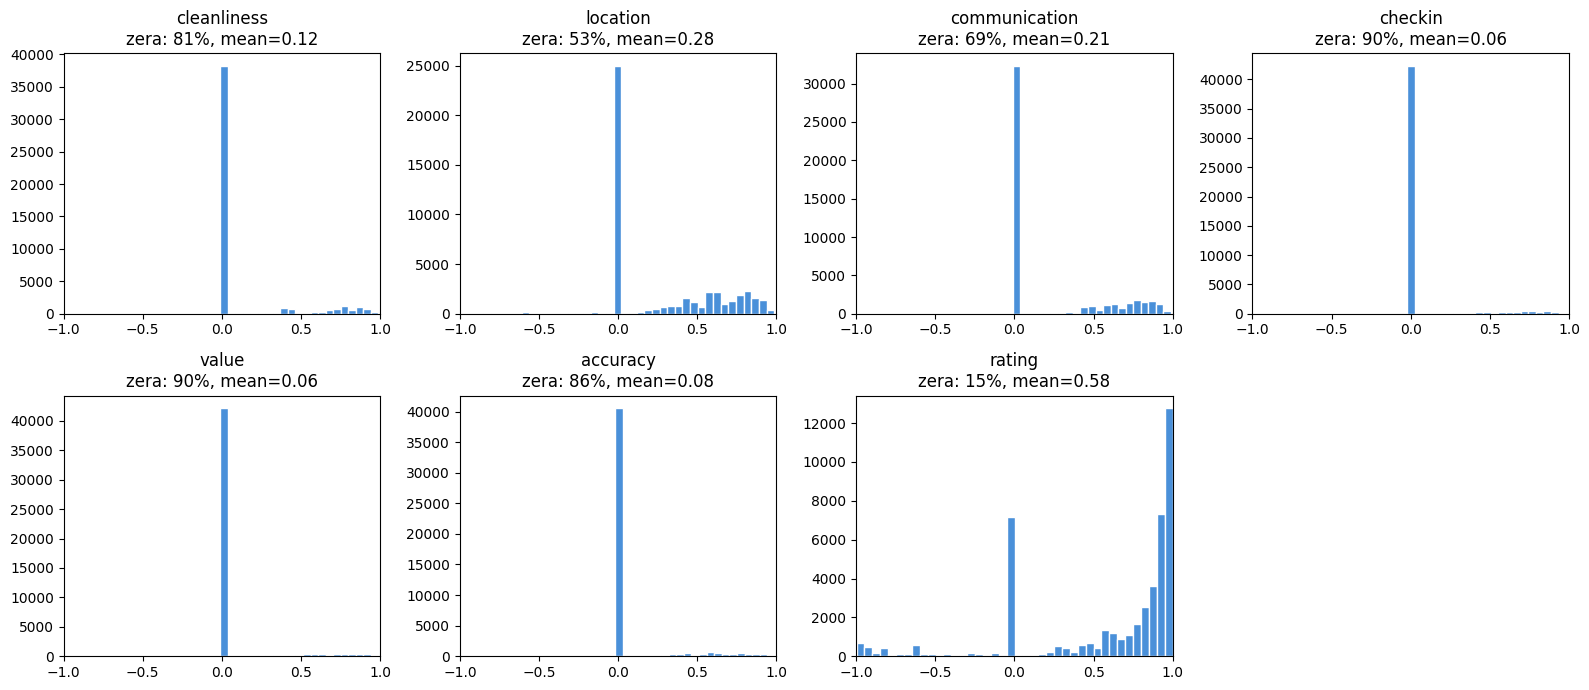

Udziały zer / dodatnich / ujemnych:
  review_scores_cleanliness            =0:  81.5%   >0:  17.8%   <0:   0.7%   mean=+0.116
  review_scores_location               =0:  53.1%   >0:  45.3%   <0:   1.5%   mean=+0.276
  review_scores_communication          =0:  68.9%   >0:  30.7%   <0:   0.4%   mean=+0.211
  review_scores_checkin                =0:  90.2%   >0:   9.1%   <0:   0.7%   mean=+0.056
  review_scores_value                  =0:  89.8%   >0:   9.7%   <0:   0.5%   mean=+0.058
  review_scores_accuracy               =0:  86.4%   >0:  13.2%   <0:   0.4%   mean=+0.078
  review_scores_rating                 =0:  15.2%   >0:  76.4%   <0:   8.4%   mean=+0.582


In [14]:
sentiment_cols = [c for c in reviews_df_scored.columns if c.startswith('review_scores_')]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(sentiment_cols):
    ax = axes[i]
    vals = reviews_df_scored[col]
    ax.hist(vals, bins=40, color='#4a90d9', edgecolor='white')
    ax.set_title(f"{col.replace('review_scores_', '')}\nzera: {(vals == 0).mean()*100:.0f}%, mean={vals.mean():.2f}")
    ax.set_xlim(-1, 1)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print("Udziały zer / dodatnich / ujemnych:")
for col in sentiment_cols:
    v = reviews_df_scored[col]
    print(f"  {col:35s}  =0: {(v == 0).mean()*100:5.1f}%   >0: {(v > 0).mean()*100:5.1f}%   <0: {(v < 0).mean()*100:5.1f}%   mean={v.mean():+.3f}")

Conclusions:

- the global `rating` has the most non-zero values,
- aspect scores contain many zeros, especially `checkin`, `value` and `accuracy`,
- some zeros mean the aspect was not mentioned, but some come from non-English reviews.

In [15]:
reviews_df_scored.iloc[5]["comments"]

'A cosy apartment with almost everything you need, esp well equipped kitchen. Very nice and quite neighbourhood.'

In [16]:
reviews_df_scored.iloc[5]

listing_id                                                              10595718
date                                                         2017-01-24 00:00:00
comments                       A cosy apartment with almost everything you ne...
review_scores_cleanliness                                                    0.0
review_scores_location                                                    0.4754
review_scores_communication                                                  0.0
review_scores_checkin                                                        0.0
review_scores_value                                                       0.2732
review_scores_accuracy                                                    0.2732
review_scores_rating                                                      0.6361
Name: 9, dtype: object

## Saving the results

The raw comment text is no longer needed. We keep the cleaned tables with the sentiment columns attached.

In [17]:
reviews_df_scored = reviews_df_scored.drop(columns=['comments'])  # sentiment scores are the downstream representation

print("=== Reviews dtypes ===")
print(reviews_df_scored.dtypes)
print("\n=== Sessions dtypes ===")
print(sessions_df_clean.dtypes)
print("\n=== Listings dtypes ===")
print(listing_df.dtypes)

reviews_df_scored.to_csv("../data/interim/reviews_processed.csv", index=False)
sessions_df_clean.to_csv("../data/interim/sessions_processed.csv", index=False)
listing_df.to_csv("../data/interim/listings_processed.csv", index=False)

=== Reviews dtypes ===
listing_id                              Int64
date                           datetime64[us]
review_scores_cleanliness             float64
review_scores_location                float64
review_scores_communication           float64
review_scores_checkin                 float64
review_scores_value                   float64
review_scores_accuracy                float64
review_scores_rating                  float64
dtype: object

=== Sessions dtypes ===
action                   str
user_id                Int64
timestamp     datetime64[us]
listing_id             Int64
dtype: object

=== Listings dtypes ===
listing_id                  Int64
property_type                 str
room_type                     str
accommodates                Int64
bedrooms                    Int64
price                     float64
neighbourhood_cleansed        str
host_is_superhost             str
host_acceptance_rate      float64
minimum_nights            float64
minimum_maximum_nights    flo